### PTE Prefetcher
* Translation-Only Tree-Aware Micro-Prefetcher
  - Goal: reduce PTW stall time, not maximize raw TXVC hit rate.(?)
  - Scope: only run when type == TRANSLATION.
  - Aggressiveness: start with degree 1, confidence-gated.
  - Safety: strict throttles and usefulness feedback.

* Core predictor components:

  * Translation stream table
    - Key: hashed requester IP plus translation level (if available).
    - State: last line, last delta, 2-bit confidence.
    - Trigger: issue one prefetch when the same delta repeats.

  * Page-table sibling predictor
    - Key: parent page-table page tag.
    - Idea: nearby virtual pages tend to touch nearby child PTEs; prefetch neighboring cache line within same page-table page, not blind global plus-one.
    - Constraint: never cross page-table-page boundary.
  
  * Usefulness controller
    - Track prefetched lines that become demand hits.
    - If rolling accuracy drops below threshold (for example 20%), auto-reduce degree to 0 until recovery.
    - Also gate on MSHR pressure like existing prefetchers do (same style as ip_stride.cc:67).

* Why it is better than naive plus-one:
  - It is still sequential-friendly when locality exists.
  - It avoids always assuming contiguous physical PTE layout.
  - long-tail regions? maybe this is why it doesn't work well for our case?

* Implementation notes:
  - using prefetcher metadata to add is_instr, translation_level 

* TXVC admission filter: (TODO)
  - Keep 2+ admission for demand fills.
  - For prefetch fills, apply stricter admission:
    - admit only if predictor confidence high, or
    - admit only for upper-level PTEs, or
    - admit into a tiny prefetch probation region (1 way per set).
    - Prevents low-value prefetched PTEs from displacing proven LFU residents.

* Evaluation:
  - Translation MPKI and average PTW latency.
  - IPC
  - Prefetch accuracy, coverage, and timeliness.
  - Pollution indicators: demand miss increase in L2/TXVC after enabling prefetch.
  - Breakdown by PTE level and by instruction/data streams.

  - Goal:
    - Keep prefetch accuracy above about 25% and MSHR pressure stable.
    - Accept lower TXVC hit-rate gains if PTW latency and IPC improve; this workload can benefit from latency hiding more than reuse capture.





### Prefetcher Implementation 

* Trigger on TXVC (demand) misses
* MSHR gating
  - do not issue prefetch if occupacy > N
* Optional: usefull_pf/useless_pf > M, else stop
  - Not sure when to resume

1. Stride Prefetcher:
  - Intuition:
    - If the PTW has been accessing PTE cache lines with a consistent stride, 
      predict the next one. (Global)

  - Prediction table:
    - cache line address
    - stride observed between the two last accesses
    - confidence, how many times this was observed
  
  - Limitatios:
    - Global context:
      - Can alias across different PTW levels
      - Can alias accross different code paths

    - Can prefetch across PT page boundaries (maybe fix?)


2. Siblings Prefetcher
  - Intuition:
    - PTEs for consecutive virtual pages share the same 4KB page-table page
    - If PTW accesses offset N within a PT page and then offset N+1, it will likely need N+2
    - The predictor tracks this intra-page stride
    - No cross-page prefetching
```text
    Physical memory of a page-table page (4KB):
    ┌────────────────────────────┐ 
    │ 4KB Page-Table Page        │
    ├─────┬─────┬─────┬─────┬────│
    │CL 0 │CL 1 │CL 2 │CL 3 │... │  <- 64-byte cache lines (offsets 0–63)
    │PTE  │PTE  │PTE  │PTE  │    │
    │0–7  │8–15 │16–23│24–31│    │
    └─────┴─────┴─────┴─────┴────| 

    PTW accesses the SAME physical PT page (0xDEAD_0000), 
    but at different cache-line offsets within it:

    0xDEAD_0180  <- offset 3 (CL 3 of page)
    0xDEAD_01C0  <- offset 4 (CL 4 of page)
    0xDEAD_0200  <- offset 8 (CL 8 of page)

    Offsets: 3 -> 4 -> 8
    Deltas learned: +1, +4

    When we see offset 8 again → predict offset 8+4=12
    Always stays within the same 4KB page (offsets 0–63)
```
  - Predictor table:
    - Tag: id of the 4KB page
      - One entry per page
    - last offset observed
    - last stride observed (within page)
    - confindence: how many times this was observed
    - usefulness: was last time useful(?) (maybe start with 0 so it doesn't stop due to this metric)

  - Candidate is offset + k*delta (within page boundries)
    - k is how many candidates to look for, for now keep at 1, else multiple prefetches.


3. Child Prefetcher
  - Intuition:
    - A page walk is a chain of dependent loads: L5 -> L4 -> L3 -> L2 -> L1. 
    - If miss on first levels, we have to wait for it to be fetched to find the child (which will probably also result in a miss)
    - Try to learn IPs that walk the same virtual address range
    - Prefetch speculative child/children

  - Predictor table: (IP, parent_addr) -> child_addr
    - Index: IP hashd with PTE address
    - Child address: predicted child addr
    - confidence: how many times we observed this
  
  - Training table: last miss seen at each level
    - Index: IP % size
    - PTE address
    - PTE level

  - On miss:
    - Check training table[ip]
      - if it holds L+1 from the same ip, the current PTE is the child
    
    - Move (ip, L+1 addr) -> child addr to predictor table
      - Update confidence (+1 if match, reset otherwise)
    
    - Update training table:
      (ip, current pte addr, level) -> none/pending
    
    - If level > 1 (Leaf), emit prediction


  

### First evaluation with unlimited prediction table sizes

In [ ]:
./scripts/manage_experiment.py --config exp_conf/txvc_prefetch_eval_unlimited.ini --build --run

In [ ]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config ./exp_conf/txvc_prefetch_eval_unlimited.ini --parse

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'TXVC_64KB_pf-none_missft-txvc_prefetchft_txvc', 'TXVC_64KB_pf-stride_missft-txvc_prefetchft_txvc_gate-75_thld-2_tblsize-65536', 'TXVC_64KB_pf-sblg_missft-txvc_prefetchft_txvc_gate-75_thld-2_tblsize-65536_degree-1_accthld-0_accwindow-32', 'TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-2_tblsz-65536_pendingsz-65536']
Plotting txvc_prefetch_eval_unlimited for selected_qualcomm_srv_ap
['BASELINE', 'None', 'Stride', 'Sibling', 'Child']
       tag  IPC_IMPROVEMENT
3   Stride         4.022546
2  Sibling         3.153723
0    Child         2.745446
1     None         2.729139
None:3.3345474596186215
Stride:4.160450934171244
Sibling:3.653597391956824
Child:3.3547355867241064
  benchmarks      tag      mean
0       mean     None  3.334547
1       mean   Stride  4.160451
2       mean  Sibling  3.653597
3       mean    Child  3.354736
  benchmarks      tag      mean
0       mean     None  3.334547
1     

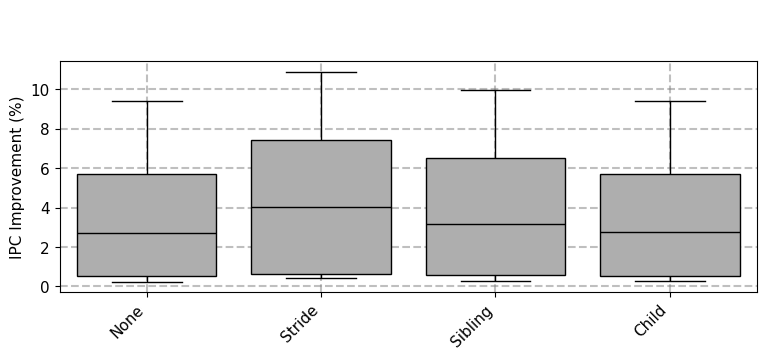

In [4]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config ./exp_conf/txvc_prefetch_eval_unlimited.ini --plot

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_prefetch_eval_unlimited_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))



***
### Prefetcher Analysis

1. Predictor entry survivability
  - Do entries last long enough to identify prefetch patterns?
  - Replacement rate -> (replacements / allocations) * 100
  - Replacement before issue rate -> (repl_before_issue / repl) * 100
  - Active Entry rate -> number of entries that are valid and have issued at least one prefetch
    - It is only a snapshot at the end, but for large tables it should be representative


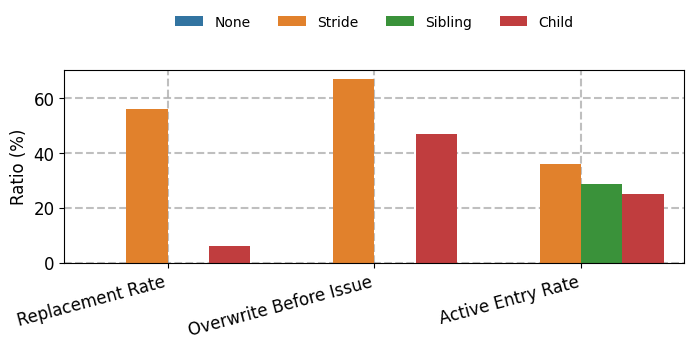

In [12]:
from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_prefetch_eval_unlimited_txvc_prefetcher_survivability_selected_qualcomm_srv_ap.png", 
width=600, height=600))

* Expected results are zero for replacement and overwite before issue
  - Stride use address bit % size, probably there is still aliasing because it's direct mapped.
  - Child has a lot of overwrite before using, thus lacking coverage, even after addressing the indexing
    - training table: hash(pc, level, virtual_page_num)
    - predictor table: hash(pc, pte_address, virtual_page_num)

* Active Entry rate
  - Low at then end probably means it never warmed up...
  - probably now a patter/perdictor accuracy issue, not replacement in the tables

### Analysis of Prefetch lifetime and usefulness
* Evicted without use -> was evicted without a demand-hit
* Evicted after user -> was evicted but there was at least one demmand hit before

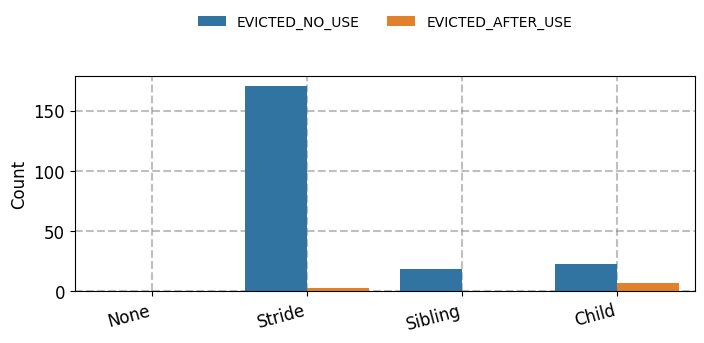

In [13]:
from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_prefetch_eval_unlimited_txvc_prefetch_failure_split_selected_qualcomm_srv_ap.png", 
width=600, height=600))

- Stride:  high pollution/untimely behavior.
- Child: better precision, low volume.

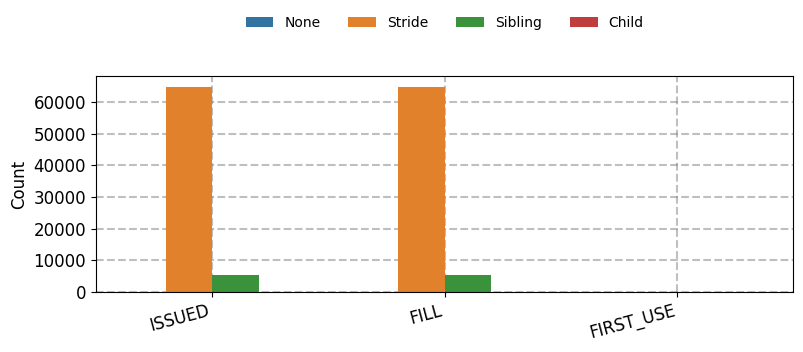

In [14]:
from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_prefetch_eval_unlimited_txvc_prefetch_funnel_selected_qualcomm_srv_ap.png", 
width=600, height=600))

- Child issued only 134 vs Stride 64,873 and Sibling 5,305.
- Child FIRST_USE 7.51 on 134 issued is much better ratio than others, but absolute count is too low to improve IPC much.

### Result Analysis
1. Stride gives the biggest IPC gain, but with massive prefetch volume and very poor usefulness.
2. Sibling is lower IPC gain, much lower traffic than stride, but still low absolute usefulness.
3. Child is very selective (very low issued), has the best relative usefulness, but too little coverage to move IPC much.




***
### Improve Child Prefetcher
- Current version probably too restrictive
- Try lower confidence 
- Try relaxing prediction indexing (or fallback if strict indexing produces no results)



In [ ]:
./scripts/manage_experiment.py --config exp_conf/txvc_child_prefetch_eval.ini --build --run

In [ ]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/txvc_child_prefetch_eval.ini --parse --plot

/home/bscuser/synched_mnt/VMem
Preprocessing configuration file...
['BASELINE', 'TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1']
Plotting txvc_child_prefetch_eval for selected_qualcomm_srv_ap
['BASELINE', 'Child', 'Child-train-on-hit']
     tag  IPC_IMPROVEMENT
0  Child         2.723143
Child:3.351379539726039
  benchmarks    tag     mean
0       mean  Child  3.35138
  benchmarks    tag     mean
0       mean  Child  3.35138
./figures/txvc_prefetch_eval/txvc_child_prefetch_eval_ipc_selected_qualcomm_srv_ap.pdf
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
Plotting completed successfully
['BASELINE', 'TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1']
Plotting txvc_child_prefetch_eval for selected_qualcomm_srv_ap
                   metric    tag       mean
0        Repl

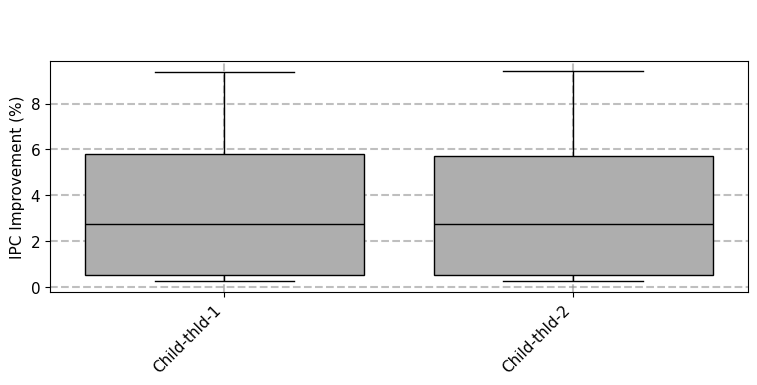

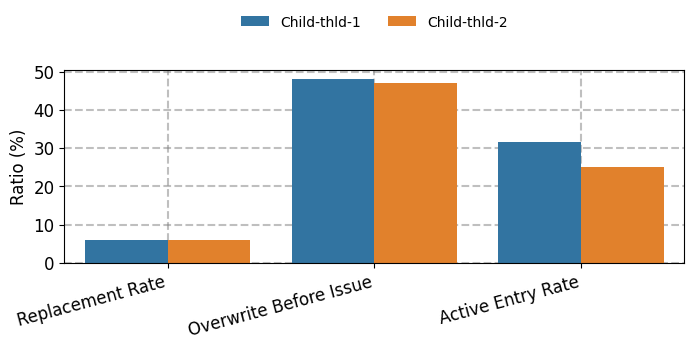

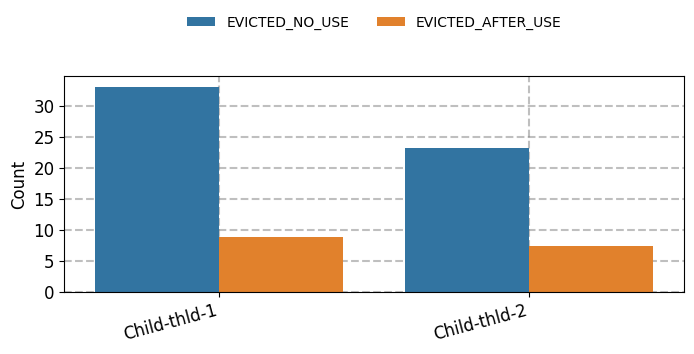

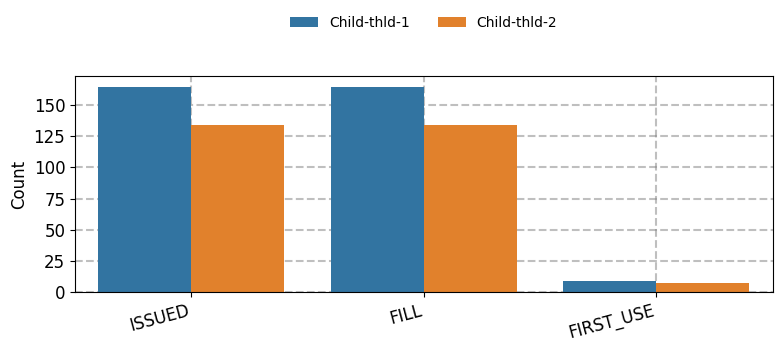

In [5]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/txvc_child_prefetch_eval.ini --plot

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval_txvc_prefetcher_survivability_selected_qualcomm_srv_ap.png", 
width=600, height=600))

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval_txvc_prefetch_failure_split_selected_qualcomm_srv_ap.png", 
width=600, height=600))

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval_txvc_prefetch_funnel_selected_qualcomm_srv_ap.png", 
width=600, height=600))

***
### Prefetcher Analysis

1. Predictor entry survivability
  - Do entries last long enough to identify prefetch patterns?

Figure 1:
* not_eligible_pct: it's a leaf node, fraction of total child events that were out of prediction scope by design
* no_parent_ctx_pct: no parent found in the training table
* predictor_miss_pct: no entry found or entry did not match hash in prediction table 
* conf_blocked_pct: blocked by confidence counter
* backend_blocked_pct: blocked by lack of backend resources (MSHR full)
* issued_pct: actual percentage of entries that issued a prefetch

Figure 2: 
  - child_potential_coverage_pct: issued and blocked predictions
  - child_realized_coverage_pct: only issued predictions

Auto-loaded 100 benchmark rows from /home/bscuser/synched_mnt/VMem/stats/txvc_prefetch_eval/TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1/selected_qualcomm_srv_ap_TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1.csv


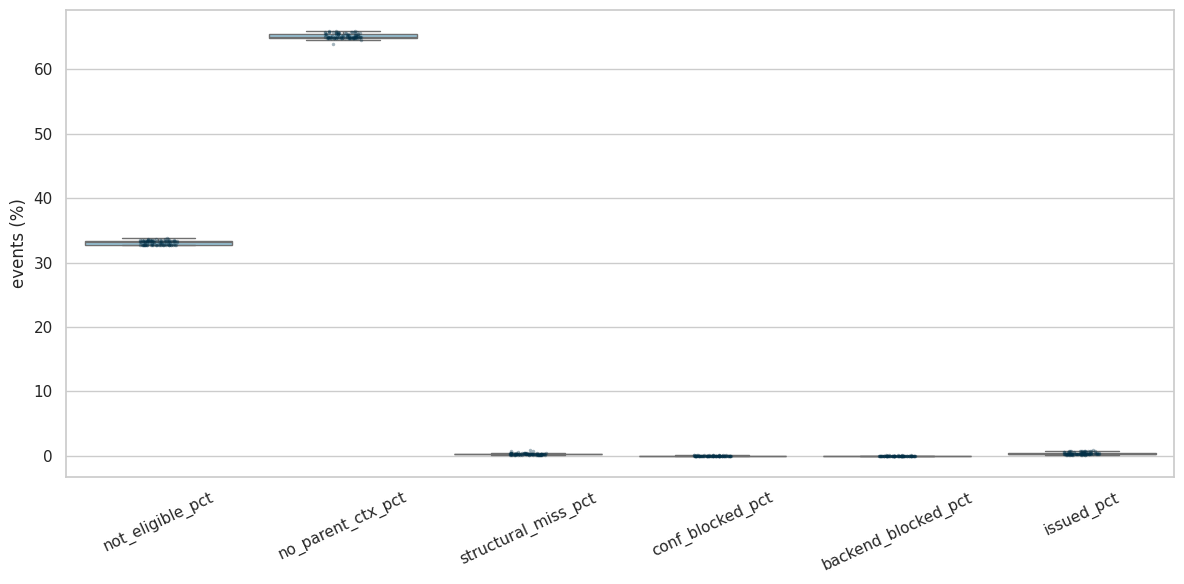

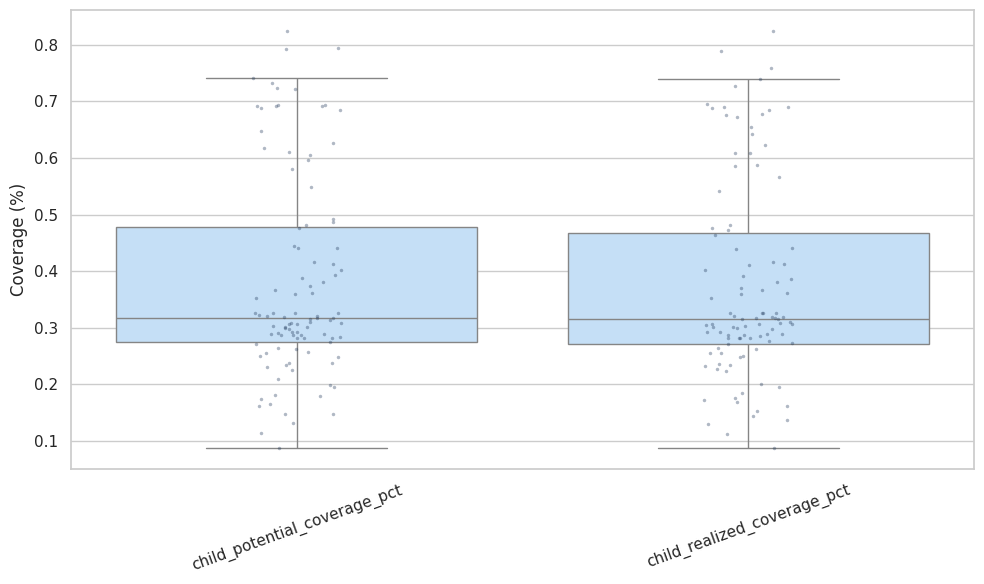

Saved PDF: /home/bscuser/synched_mnt/VMem/figures/txvc_prefetch_eval/txvc_child_stage_share_boxplot.pdf
Saved PDF: /home/bscuser/synched_mnt/VMem/figures/txvc_prefetch_eval/txvc_child_coverage_boxplot.pdf


,__bench,TXVC_CHILD_DROP_PRED_ISSUED,TXVC_CHILD_DROP_NO_PENDING_PARENT,child_not_eligible,child_structural_miss,TXVC_CHILD_DROP_PRED_CONF_BLOCKED,child_backend_blocked,child_potential_coverage_pct,child_realized_coverage_pct
4160,srv56_ap,171.0,130302.0,65979.0,195.0,2.0,1.0,0.087035,0.086529
4741,srv358_ap,222.0,129559.0,66038.0,196.0,14.0,2.0,0.113678,0.112663
4487,srv45_ap,259.0,131962.0,67174.0,115.0,19.0,3.0,0.130628,0.129133
567,srv509_ap,77.0,37010.0,18717.0,85.0,0.0,6.0,0.147155,0.136518
224,srv137_ap,91.0,41673.0,20930.0,96.0,1.0,2.0,0.147056,0.143894
75,srv366_ap,109.0,47227.0,23741.0,99.0,0.0,9.0,0.164639,0.152082
4224,srv662_ap,321.0,130917.0,66904.0,172.0,1.0,2.0,0.161948,0.160945
345,srv602_ap,116.0,45444.0,22875.0,179.0,1.0,9.0,0.180931,0.167904
3366,srv506_ap,344.0,132438.0,66848.0,142.0,36.0,7.0,0.174780,0.171294
241,srv160_ap,109.0,40722.0,20579.0,65.0,0.0,2.0,0.179333,0.176102


In [ ]:
# Boxplots across benchmarks (threshold-1 child runs)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Resolve workspace root whether the notebook runs from repo root or notebooks/.
base_dir = Path.cwd()
if not (base_dir / "stats").exists() and (base_dir.parent / "stats").exists():
    base_dir = base_dir.parent

# Output directory for exported figures
pdf_out_dir = base_dir / "figures" / "txvc_prefetch_eval"
pdf_out_dir.mkdir(parents=True, exist_ok=True)

# Use existing prepared dataframe when available; otherwise auto-load a compatible parsed CSV.
if "d" in globals() and isinstance(d, pd.DataFrame) and not d.empty:
    box_df = d.copy()
else:
    preferred = [
        base_dir / "stats/txvc_prefetch_eval/TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1/selected_qualcomm_srv_ap_TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1.csv",
    ]
    fallback = sorted((base_dir / "stats/txvc_prefetch_eval").glob("**/*thld-1*/*.csv"))
    candidates = preferred + fallback

    required_raw = [
        "TXVC_CHILD_DROP_LEVEL0_SKIP",
        "TXVC_CHILD_DROP_LEAF_NO_PREDICT",
        "TXVC_CHILD_DROP_NO_PENDING_PARENT",
        "TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION",
        "TXVC_CHILD_DROP_PRED_INVALID",
        "TXVC_CHILD_DROP_PRED_TAG_MISMATCH",
        "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
        "TXVC_CHILD_DROP_PRED_ISSUED",
        "TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED",
        "TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED",
    ]

    box_df = None
    loaded_path = None
    for p in candidates:
        if not p.exists():
            continue
        try:
            tmp = pd.read_csv(p)
        except Exception:
            continue
        if all(c in tmp.columns for c in required_raw):
            box_df = tmp
            loaded_path = p
            break

    if box_df is None:
        raise RuntimeError(
            "Could not find a parsed CSV with TXVC child drop columns under stats/txvc_prefetch_eval. "
            "Run --parse first, or provide dataframe d in a previous cell."
        )

    if "__bench" not in box_df.columns:
        if "benchmarks" in box_df.columns:
            box_df["__bench"] = box_df["benchmarks"].astype(str).str.strip()
        else:
            box_df["__bench"] = "unknown"

    for c in required_raw:
        box_df[c] = pd.to_numeric(box_df[c], errors="coerce").fillna(0)

    # Keep one representative row per benchmark to avoid duplicate rows from merged outputs.
    box_df["_child_total"] = box_df[required_raw].sum(axis=1)
    box_df = box_df.sort_values("_child_total", ascending=False).drop_duplicates("__bench").copy()
    print(f"Auto-loaded {len(box_df)} benchmark rows from {loaded_path}")

# Build composite counters when they are not already present in d.
if "child_not_eligible" not in box_df.columns:
    box_df["child_not_eligible"] = (
        box_df["TXVC_CHILD_DROP_LEVEL0_SKIP"] + box_df["TXVC_CHILD_DROP_LEAF_NO_PREDICT"]
    )
if "child_structural_miss" not in box_df.columns:
    box_df["child_structural_miss"] = (
        box_df["TXVC_CHILD_DROP_PRED_INVALID"] + box_df["TXVC_CHILD_DROP_PRED_TAG_MISMATCH"]
    )
if "child_backend_blocked" not in box_df.columns:
    box_df["child_backend_blocked"] = (
        box_df["TXVC_CHILD_DROP_ISSUE_MSHR_BLOCKED"] + box_df["TXVC_CHILD_DROP_ISSUE_ENQUEUE_FAILED"]
    )

# Stage components for distribution plots
stage_budget = (
    box_df["child_not_eligible"]
    + box_df["TXVC_CHILD_DROP_NO_PENDING_PARENT"]
    + box_df["TXVC_CHILD_DROP_PENDING_OVERWRITE_COLLISION"]
    + box_df["child_structural_miss"]
    + box_df["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"]
    + box_df["TXVC_CHILD_DROP_PRED_ISSUED"]
    + box_df["child_backend_blocked"]
).replace(0, np.nan)

box_df["not_eligible_pct"] = 100.0 * box_df["child_not_eligible"] / stage_budget
box_df["no_parent_ctx_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_NO_PENDING_PARENT"] / stage_budget
box_df["structural_miss_pct"] = 100.0 * box_df["child_structural_miss"] / stage_budget
box_df["conf_blocked_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_CONF_BLOCKED"] / stage_budget
box_df["backend_blocked_pct"] = 100.0 * box_df["child_backend_blocked"] / stage_budget
box_df["issued_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / stage_budget

if "child_potential_coverage_pct" not in box_df.columns:
    box_df["child_potential_coverage_pct"] = 100.0 * (
        box_df["TXVC_CHILD_DROP_PRED_ISSUED"] + box_df["child_backend_blocked"]
    ) / stage_budget
if "child_realized_coverage_pct" not in box_df.columns:
    box_df["child_realized_coverage_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / stage_budget
if "child_backend_feasibility_pct" not in box_df.columns:
    attempt = box_df["TXVC_CHILD_DROP_PRED_ISSUED"] + box_df["child_backend_blocked"]
    box_df["child_backend_feasibility_pct"] = 100.0 * box_df["TXVC_CHILD_DROP_PRED_ISSUED"] / attempt.replace(0, np.nan)

# 1) Distribution of stage shares across benchmarks
stage_metrics = [
    "not_eligible_pct",
    "no_parent_ctx_pct",
    "structural_miss_pct",
    "conf_blocked_pct",
    "backend_blocked_pct",
    "issued_pct",
]
stage_long = box_df.melt(value_vars=stage_metrics, var_name="metric", value_name="pct")

plt.figure(figsize=(12, 6))
sns.boxplot(data=stage_long, x="metric", y="pct", color="#8ecae6", showfliers=False)
sns.stripplot(data=stage_long, x="metric", y="pct", color="#023047", size=2.5, alpha=0.35)
plt.title("")
plt.xlabel("")
plt.ylabel("events (%)")
plt.xticks(rotation=25)
plt.tight_layout()
stage_pdf = pdf_out_dir / "txvc_child_stage_share_boxplot.pdf"
plt.savefig(stage_pdf, format="pdf", bbox_inches="tight")
plt.show()

# 2) Coverage/feasibility distributions across benchmarks
cov_metrics = [
    "child_potential_coverage_pct",
    "child_realized_coverage_pct"
]
cov_long = box_df.melt(value_vars=cov_metrics, var_name="metric", value_name="pct")

plt.figure(figsize=(10, 6))
sns.boxplot(data=cov_long, x="metric", y="pct", color="#bde0fe", showfliers=False)
sns.stripplot(data=cov_long, x="metric", y="pct", color="#1d3557", size=2.5, alpha=0.35)
plt.title("")
plt.xlabel("")
plt.ylabel("Coverage (%)")
plt.xticks(rotation=20)
plt.tight_layout()
coverage_pdf = pdf_out_dir / "txvc_child_coverage_boxplot.pdf"
plt.savefig(coverage_pdf, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved PDF: {stage_pdf}")
print(f"Saved PDF: {coverage_pdf}")

# 3) Optional: top benchmark outliers for quick debugging
outlier_view = box_df[[
    "__bench",
    "TXVC_CHILD_DROP_PRED_ISSUED",
    "TXVC_CHILD_DROP_NO_PENDING_PARENT",
    "child_not_eligible",
    "child_structural_miss",
    "TXVC_CHILD_DROP_PRED_CONF_BLOCKED",
    "child_backend_blocked",
    "child_potential_coverage_pct",
    "child_realized_coverage_pct",
]].copy()

outlier_view.sort_values("child_realized_coverage_pct", ascending=True).head(15)

### Train Child prefetcher on Hit evaluation

In [ ]:
!./scripts/manage_experiment.py --config exp_conf/txvc_child_prefetch_eval.ini --override "*.txvc.pf_child_train_on_hit=0 1"  --build --run

In [1]:
%cd /home/bscuser/synched_mnt/VMem
!./scripts/manage_experiment.py --config exp_conf/txvc_child_prefetch_eval.ini --override "*.txvc.pf_child_train_on_hit=0 1" --parse

/home/bscuser/synched_mnt/VMem


Override applied: *.txvc.pf_child_train_on_hit='0 1' to 2 experiment section(s).
Preprocessing configuration file...
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/txvc_prefetch_eval/BASELINE', './data/txvc_prefetch_eval']
/home/bsc/bsc018186/.bashrc: line 2: module: command not found
/home/bsc/bsc018186/.bashrc: line 3: module: command not found
/home/bsc/bsc018186/.bashrc: line 4: module: command not found
/home/bsc/bsc018186/.bashrc: line 5: module: command not found
receiving incremental file list

sent 51 bytes  received 4,227 bytes  1,222.29 bytes/sec
total size is 2,416,552  speedup is 564.88
Parsing results for BASELINE...
Merging results to ./stats/txvc_prefetch_eval/BASELINE/selected_qualcomm_srv_ap_BASELINE.csv
Parsing completed successfully
['rsync', '-av', '--include=*/', '--include=*.out', '--exclude=*', 'bsc018186@transfer1.bsc.es:/gpfs/scratch/bsc18/bsc018186/VMem/data/txvc_prefetch_

Override applied: PLOTTING.plot_name='txvc_child_prefetch_eval2'
Override applied: *.txvc.pf_child_train_on_hit='0 1' to 2 experiment section(s).
Preprocessing configuration file...
['BASELINE', 'TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-0', 'TXVC_64KB_pf-child_missft-txvc_prefetchft_txvc_gate-75_thld-1_tblsz-65536_pendingsz-65536_trainonhit-1']
Plotting txvc_child_prefetch_eval2 for selected_qualcomm_srv_ap
['BASELINE', 'Child', 'Child-train-on-hit']
                  tag  IPC_IMPROVEMENT
0               Child         2.753863
1  Child-train-on-hit         2.723143
Child:3.348708660039064
Child-train-on-hit:3.351379539726039
  benchmarks                 tag      mean
0       mean               Child  3.348709
1       mean  Child-train-on-hit  3.351380
  benchmarks                 tag      mean
0       mean               Child  3.348709
1       mean  Child-train-on-hit  3.351380
./figures/txvc_prefetch_eval/txvc_child_prefetch_

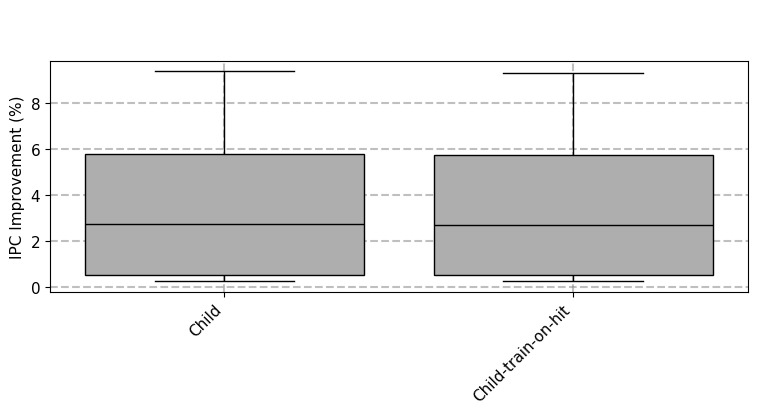

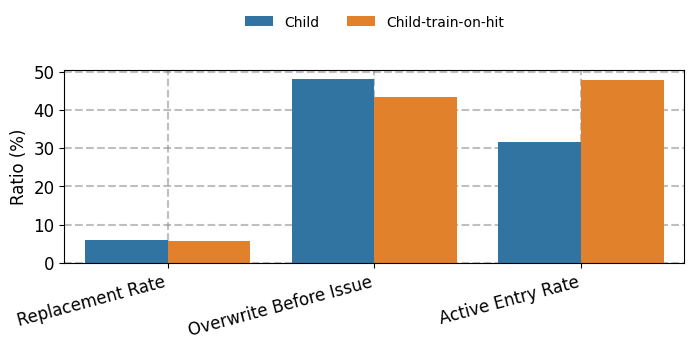

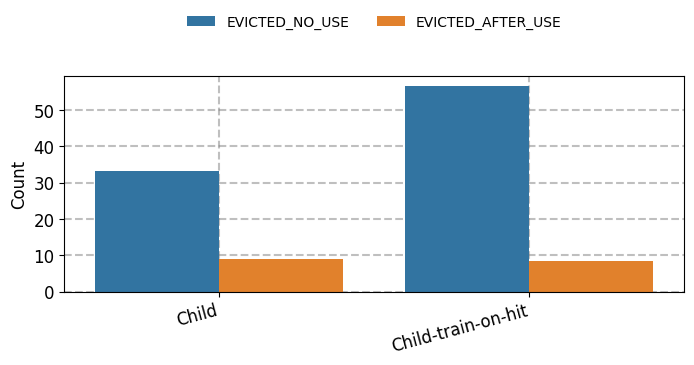

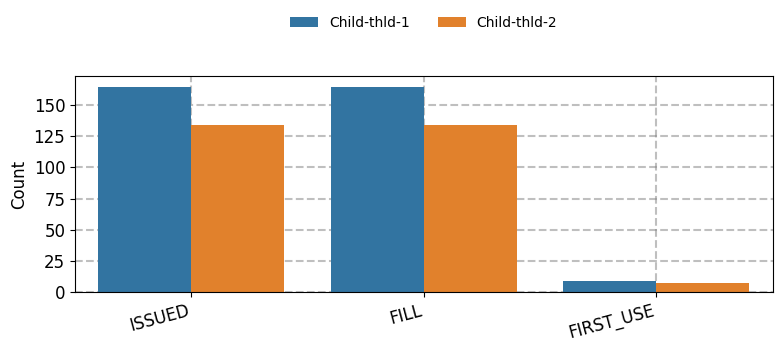

In [3]:
!./scripts/manage_experiment.py --config exp_conf/txvc_child_prefetch_eval.ini --override "PLOTTING.plot_name=txvc_child_prefetch_eval2" "*.txvc.pf_child_train_on_hit=0 1" --plot

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval2_ipc_selected_qualcomm_srv_ap.png", 
width=600, height=600))

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval2_txvc_prefetcher_survivability_selected_qualcomm_srv_ap.png", 
width=600, height=600))

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval2_txvc_prefetch_failure_split_selected_qualcomm_srv_ap.png", 
width=600, height=600))

from IPython.display import Image, display
display(Image("./figures/txvc_prefetch_eval/txvc_child_prefetch_eval_txvc_prefetch_funnel_selected_qualcomm_srv_ap.png", 
width=600, height=600))

1. Relax or have a fallback in prediction indexing (?)
2. Train on hit as well, hitting on a parent means we probably gonna need the child as well
  - Could also train on hist in L1D?
3. Move to l1d to have fewer leaf-nodes
4. Sibling predictor for leaf-nodes
  - Previous results are poor, maybe examine further sibling predictor

***
### Improvements

* Dynamic admission threshold
  - Switch between access threshold 2 and 3 based on recent miss burstiness or queue pressure.

### Morrigan-like
Short answer: partially relevant, but probably too heavy as-is for your use case.

* Learn richer access correlations than simple stride.
  - PTE streams are often non-linear, so richer correlation than plus-one/stride can find extra hits.
  - That can help with long-tail reuse.
  - Use context like walker IP, translation level, and recent deltas to predict next PTE lines.

* Use a tiny correlation table keyed by (IP hash, translation level, page-table-page tag).
  - Degree 1 by default, degree 2 only at high confidence.
  - Add strict usefulness feedback (auto-throttle when accuracy drops).

### Synergy with replacement:
* Separate LFU counters for demand and prefetched lines
* Prefetch hits should need to prove usefulness before getting full LFU weight.

***
### Event Triggered/Delayed Prefetches

* Confidence >= 2 no benefits
  - Suggests strides repeat not fast enough 


* Large reuse distance:
  - Maybe prefetches evicted before actual reuse
  - Or useless to begin with (???)


* Added some metrics:
  - useful: demand hits a prefetched entry
  - late: demand misses - prefetch is already in mshr
  - early: prefetch evicted before use
    - How to differentiate between early and useless?
      - Auxilary structure of prefetched entries?

  - Not sure now if problem is accuracy, if prefetches come late or too early in the cache (?)



* Delayed Prefetch:
  - Wait N misses (global) or X cycles for prefetch
  - Need to track/measure liveliness



* Timely Prefetch:
  - More like BERTI
    - Compute the fetching latency
    - Find the min event that allows the prefetch to arrive before the demand miss



* Prefetch + Replacement:
  - Help prefetches
  - SRRIP easy, just use different IPV equivalent
  - LFU ?? 
    - Change insertion point



* Protected Buffer/Way:
  - Only prefetches.
  - Need to weight usefulness or have separate replacment.